In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



### Phase 1: Load and Initial Reconniassance

In [4]:
# Load your preprocessed parquet or pickle
df = pd.read_parquet("../data/bts_all.parquet")  # or pd.read_pickle("flights.pkl")

df.head()

,FlightDate,Reporting_Airline,Tail_Number,Origin,Dest,CRSDepTime,DepDelay,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2020-01-17,B6,N661JB,PBI,BDL,1940,-14.0,15.0,1941.0,2212.0,6.0,2229,-11.0,1133.0,NaN,NaN,NaN,NaN,NaN
1,2020-01-18,B6,N584JB,PBI,BDL,1940,-14.0,14.0,1940.0,2207.0,13.0,2229,-9.0,1133.0,NaN,NaN,NaN,NaN,NaN
2,2020-01-19,B6,N662JB,PBI,BDL,1940,7.0,11.0,1958.0,2217.0,6.0,2229,-6.0,1133.0,NaN,NaN,NaN,NaN,NaN
3,2020-01-20,B6,N784JB,PBI,BDL,1940,-7.0,27.0,2000.0,2220.0,13.0,2229,4.0,1133.0,NaN,NaN,NaN,NaN,NaN
4,2020-01-21,B6,N784JB,PBI,BDL,1940,12.0,10.0,2002.0,2229.0,6.0,2229,6.0,1133.0,NaN,NaN,NaN,NaN,NaN


In [5]:
df[["TaxiOut", "DepDelay"]].describe()


,TaxiOut,DepDelay
count,3.460479e+07,3.461837e+07
mean,1.701429e+01,1.086318e+01
std,9.316659e+00,5.216908e+01
min,1.000000e+00,-1.280000e+02
25%,1.100000e+01,-6.000000e+00
50%,1.500000e+01,-2.000000e+00
75%,2.000000e+01,7.000000e+00
max,3.790000e+02,4.413000e+03


### Phase 2: Data Quality Assessment

In [11]:
taxi_percent_missing = len(df["TaxiOut"]) / df["TaxiOut"].isna().sum()

taxi_percent_missing

43.55630490202951

Almost half of the te taxi out column is missing.  Is that due airport reporting abilities/  Let's examine the distribution of missing values across airports.

In [16]:
# Number of missing values per airport
missing_taxis_by_airport = (
    df.groupby("Origin")
      .agg(
          total_flights=("TaxiOut", "size"),
          missing_taxiout=("TaxiOut", lambda x: x.isna().sum())
      )
      .assign(pct_missing=lambda x: x["missing_taxiout"] / x["total_flights"]*100)
      .sort_values("pct_missing", ascending=False)
)

missing_taxis_by_airport


,total_flights,missing_taxiout,pct_missing
Origin,,,
MMH,270,71,26.296296
BFM,47,7,14.893617
PGV,182,27,14.835165
ASE,36615,2986,8.155128
OGD,229,17,7.423581
...,...,...,...
CDC,3272,14,0.427873
UIN,10,0,0.000000
IPT,71,0,0.000000


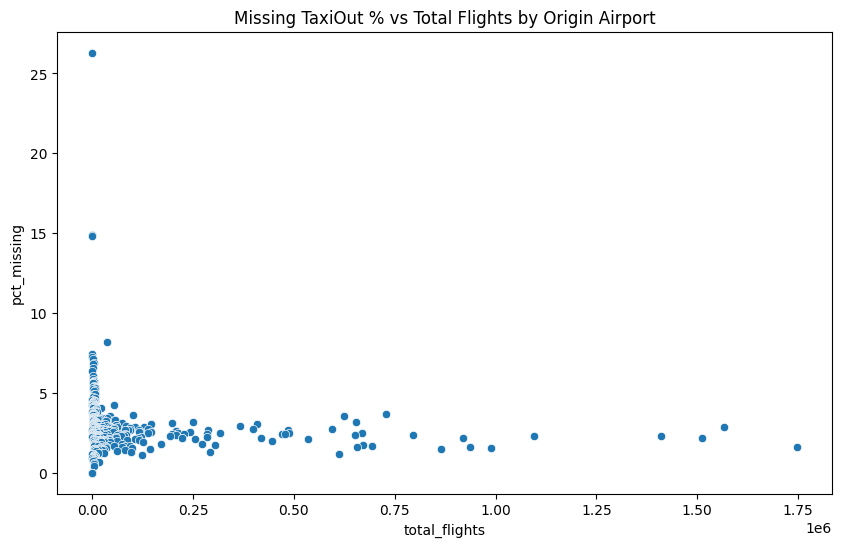

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=missing_taxis_by_airport,
    x="total_flights",
    y="pct_missing"
)

plt.title("Missing TaxiOut % vs Total Flights by Origin Airport")
plt.show()

Lower volume airports have a slightly higher percentage of missing taxi times, but even the high-volume airports have percentages in 0 to 5% range.  We will just neglect missing values in this analysis.

Now, we'll validate the TaxiOut data using domain logic.

In [21]:
# Assume Taxi Times less than 0 and greater than 24 hours are erroneous
invalid_taxi = df[(df["TaxiOut"] < 0) | (df["TaxiOut"] > 1440)]


invalid_taxi.shape


(0, 19)

In [24]:
Q1 = df["TaxiOut"].quantile(0.25)
Q3 = df["TaxiOut"].quantile(0.75)
IQR = Q3 - Q1

taxi_outliers = df[(df["TaxiOut"] < Q1 - 1.5*IQR) | (df["TaxiOut"] > Q3 + 1.5*IQR)]
outlier_pct = len(taxi_outliers)/len(df["TaxiOut"])*100
outlier_pct

4.744877878272988

Only 4% of the taxi times are considered outliers. 

### Phase 4:  Cleaning Decisions
N/A for this dataset

### Phase 5:  Statistical EDA

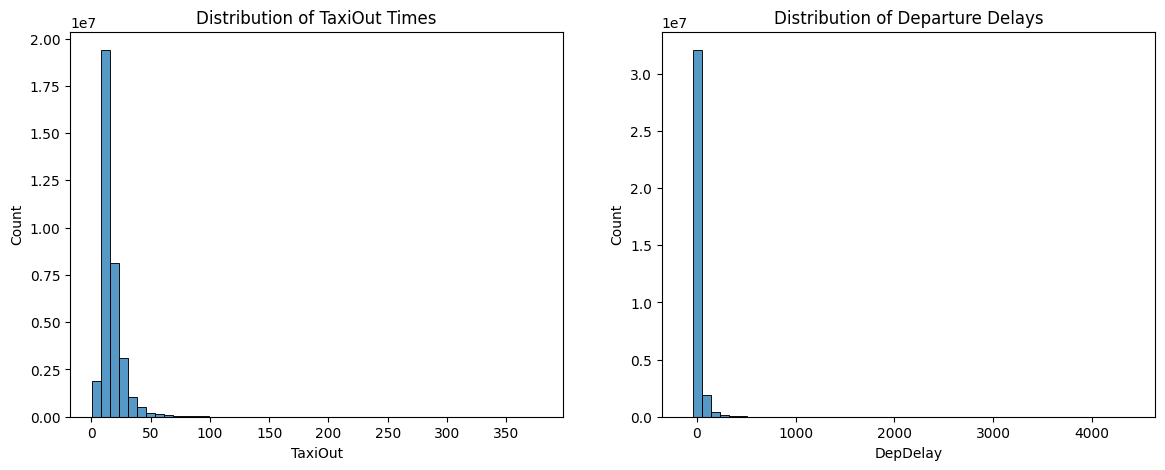

In [27]:
#Distribution of TaxiOut and Departure delays
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df["TaxiOut"], bins=50, ax=ax[0])
ax[0].set_title("Distribution of TaxiOut Times")

sns.histplot(df["DepDelay"], bins=50, ax=ax[1])
ax[1].set_title("Distribution of Departure Delays")

plt.show()


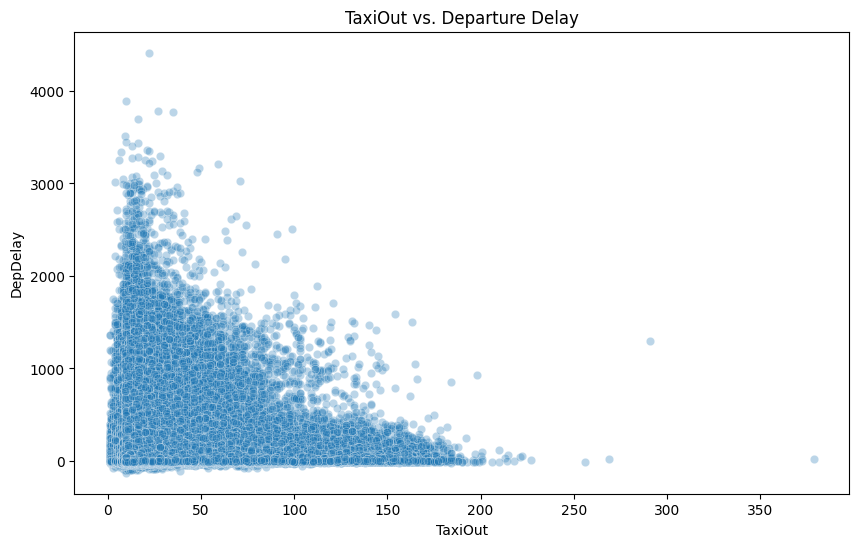

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="TaxiOut", y="DepDelay", data=df, alpha=0.3)
plt.title("TaxiOut vs. Departure Delay")
plt.show()

In [30]:
airport_stats = (
    df.groupby("Origin")
        .agg(avg_taxi=("TaxiOut","mean"),
             avg_dep_delay=("DepDelay","mean"),
             flights=("Origin","count"))
        .query("flights > 500")   # avoid small-sample noise
)

airport_stats.head()


,avg_taxi,avg_dep_delay,flights
Origin,,,
ABE,14.606443,9.648922,22906
ABI,12.897754,6.622433,10162
ABQ,13.953688,8.874226,114977
ABR,13.527533,11.211466,4045
ABY,14.466053,7.513906,4938


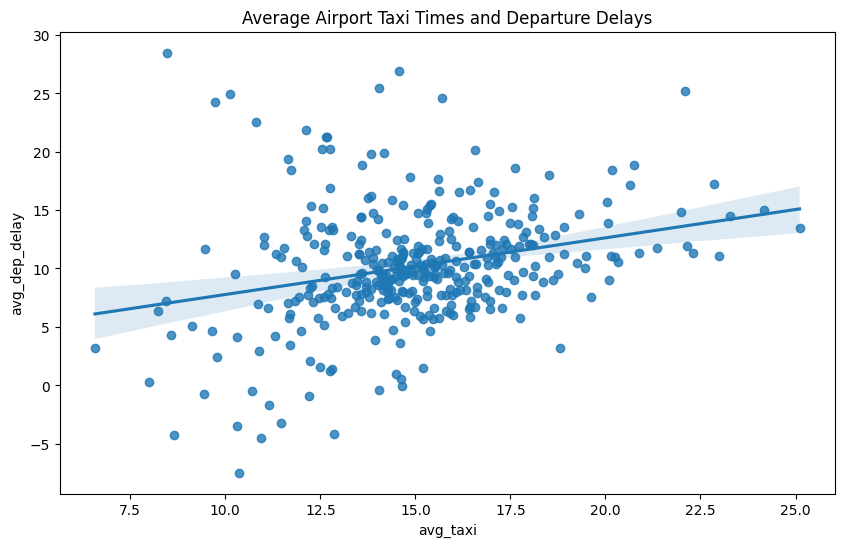

In [35]:
plt.figure(figsize=(10,6))
sns.regplot(data=airport_stats, x="avg_taxi", y="avg_dep_delay")
plt.title("Average Airport Taxi Times and Departure Delays")
plt.show()


We only detect a weak linear relationship between airport average taxi time and average departure delays.

### Phase 5: Transformation


N/A for this question

### Phase 6:  Save and Document

**Conclusion**

Average taxi times are only slightly positively related with average departure delays, indicating taxi times aren't a great contributor to departure delays.  This is probably the result of the fact that departure times already factor taxi times into the predicted departure time. 